# **Degree Distributions Plots**

# Import Libraries

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from networkx import bipartite

# Bipartite Network

In [2]:
# Load the bipartite network DataFrames
df_bipartite_edges = pd.read_csv('../data/processed/bipartite-network-edges.csv')
df_bipartite_nodes = pd.read_csv('../data/processed/bipartite-network-nodes.csv')

# Create the network
B = nx.from_pandas_edgelist(df=df_bipartite_edges, source='source', target='target')
attribute_dict = df_bipartite_nodes.set_index('id')['type'].to_dict()
nx.set_node_attributes(B, attribute_dict, 'type')

# Set the bipartite configurations
medications_set = [n for n, d in B.nodes(data=True) if d['type'] == 'medication']
side_effects_set = [n for n, d in B.nodes(data=True) if d['type'] == 'side effect']
for n, d in B.nodes(data=True):
    B.nodes[n]['bipartite'] = 0 if d['type'] == 'medication' else 1

# Compute the degree of the nodes in each partition
medications_degree, side_effects_degree = bipartite.degrees(B=B, nodes=side_effects_set)

## Medications

In [3]:
# Compute degree sequence
degree_sequence = np.array([d for _, d in medications_degree])

# Compute degree frequencies
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)

# Compute degree probabilities
degree_prob = degree_counts / degree_counts.sum()

# Compute complementary cumulative distribution function
ccdf = np.cumsum(degree_prob[::-1])[::-1]

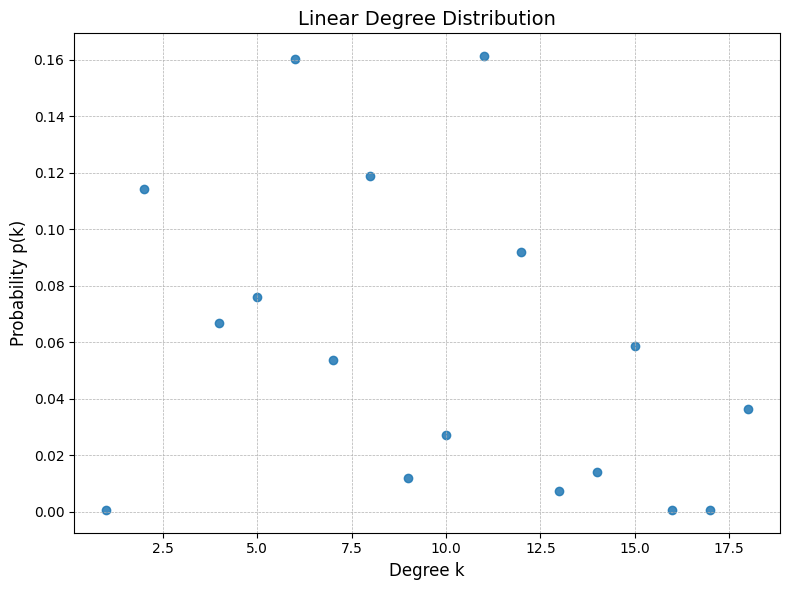

In [4]:
# Scatter plot visualization
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=degree_prob, alpha=0.85)

# Plot configuration
plt.title('Linear Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability p(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

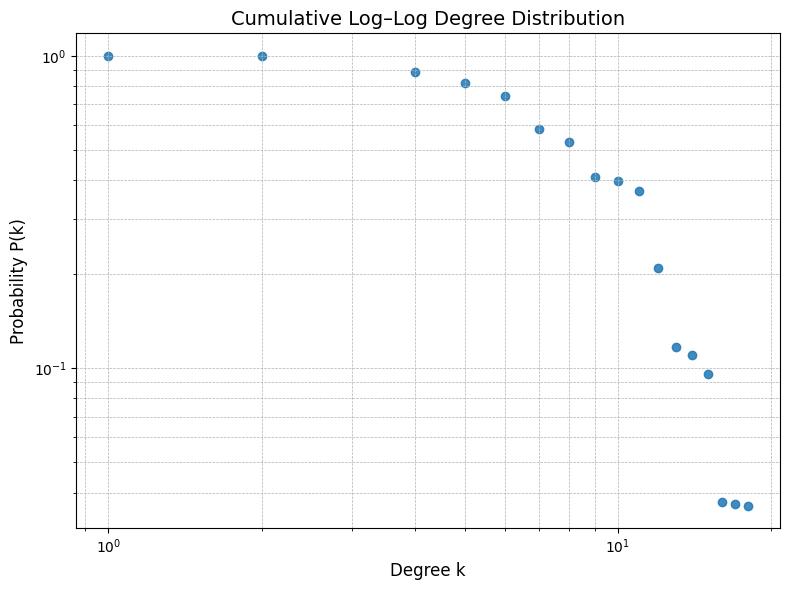

In [5]:
# Scatter plot visualization on log-log scale
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=ccdf, alpha=0.85)
plt.xscale('log')
plt.yscale('log')

# Plot configuration 
plt.title('Cumulative Log–Log Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

## Side Effects

In [6]:
# Compute degree sequence
degree_sequence = np.array([d for _, d in side_effects_degree])

# Compute degree frequencies
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)

# Compute degree probabilities
degree_prob = degree_counts / degree_counts.sum()

# Compute complementary cumulative distribution function
ccdf = np.cumsum(degree_prob[::-1])[::-1]

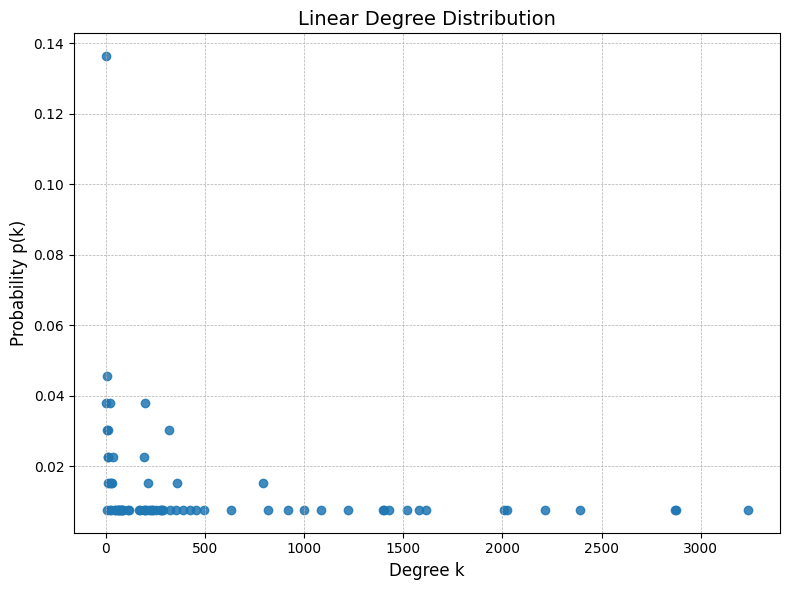

In [7]:
# Scatter plot visualization
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=degree_prob, alpha=0.85)

# Plot configuration
plt.title('Linear Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability p(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

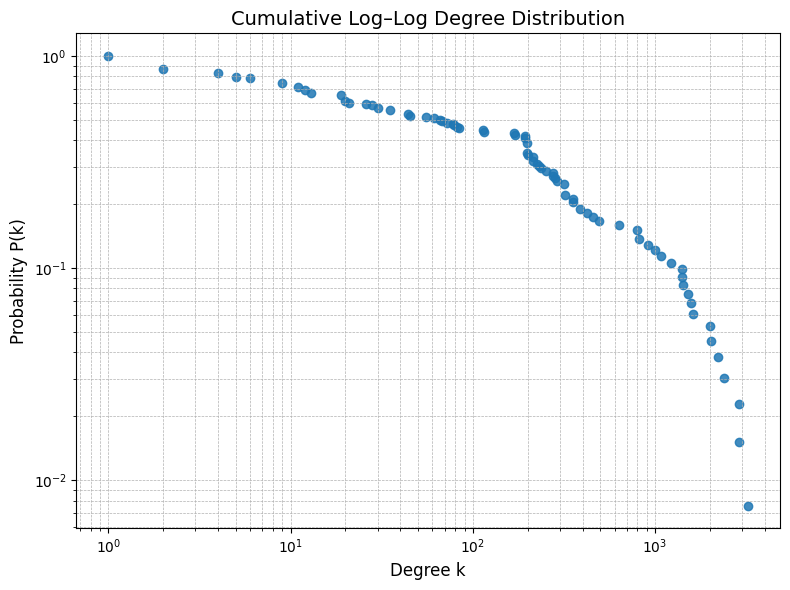

In [8]:
# Scatter plot visualization on log-log scale
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=ccdf, alpha=0.85)
plt.xscale('log')
plt.yscale('log')

# Plot configuration 
plt.title('Cumulative Log–Log Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

# Projection Network

In [9]:
# Load the projection network
df_projection = pd.read_csv('../data/processed/side-effect-projection-edges.csv')
G = nx.from_pandas_edgelist(df_projection, source='source', target='target')

# Compute degree sequence
degree_sequence = np.array([d for _, d in G.degree()])

# Compute degree frequencies
degree_values, degree_counts = np.unique(degree_sequence, return_counts=True)

# Compute degree probabilities
degree_prob = degree_counts / degree_counts.sum()

# Compute complementary cumulative distribution function
ccdf = np.cumsum(degree_prob[::-1])[::-1]

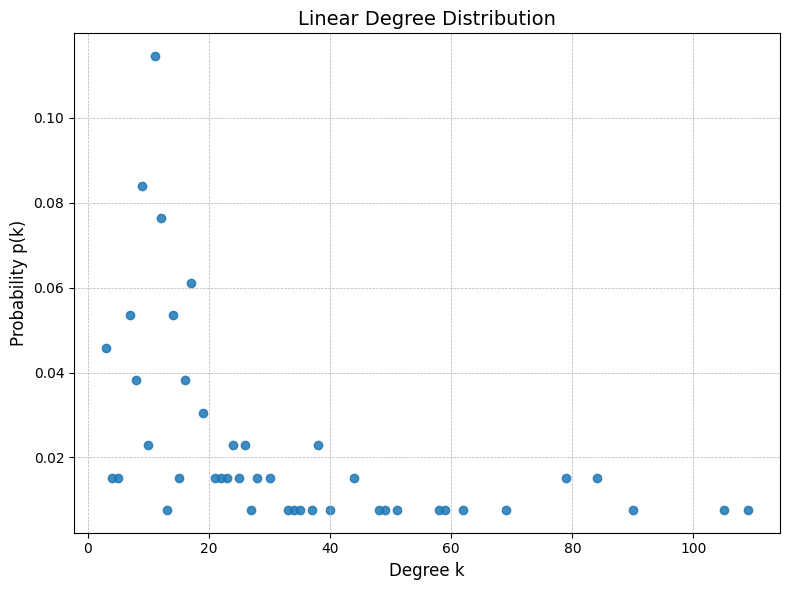

In [10]:
# Scatter plot visualization
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=degree_prob, alpha=0.85)

# Plot configuration
plt.title('Linear Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability p(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

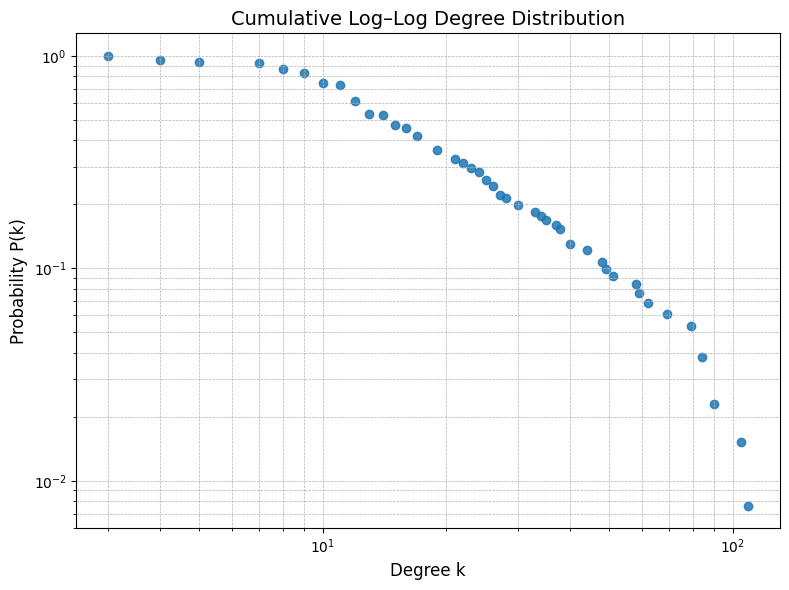

In [11]:
# Scatter plot visualization on log-log scale
plt.figure(figsize=(8, 6))
plt.scatter(x=degree_values, y=ccdf, alpha=0.85)
plt.xscale('log')
plt.yscale('log')

# Plot configuration 
plt.title('Cumulative Log–Log Degree Distribution', fontsize=14)
plt.xlabel('Degree k', fontsize=12)
plt.ylabel('Probability P(k)', fontsize=12)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()